# Дискретно-событийная модель SIR: базовый прогон

В этой модели каждый человек --- отдельный процесс. Здоровый человек
через случайные промежутки времени встречается со случайным собеседником,
и если собеседник болен, то с вероятностью $\beta$ заражается.
Больной через случайное время выздоравливает.
Встречи происходят в среднем $c$ раз в единицу времени,
а болезнь длится в среднем $1/\gamma$.

## Активация проекта и загрузка пакетов

Код модели лежит в модуле `SIRDES` в файле `src/sir_model.jl`.
Проверка `@isdefined` нужна, чтобы модуль не загружался повторно,
когда несколько скриптов выполняются в одном сеансе.

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRDES) || include(srcdir("sir_model.jl"))
using .SIRDES
using Random, StatsPlots, DataFrames, CSV

script_name = "sir_des"
mkpath(plotsdir())
mkpath(datadir("sims"))

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab08/project/data/sims"

## Параметры модели

Тысяча человек, из них десять больных. Вероятность заражения 0.05,
десять встреч в единицу времени, средняя длительность болезни 4.

In [2]:
tmax = 40.0
u0 = [990, 10, 0]      # S, I, R
p = [0.05, 10.0, 0.25] # β, c, γ

Random.seed!(1234)

TaskLocalRNG()

## Запуск модели

Сначала создаётся модель, затем для каждого человека регистрируется
процесс, и после этого запускается моделирование до момента `tmax`.

In [3]:
des_model = MakeSIRModel(u0, p)
activate(des_model)
sir_run(des_model, tmax)
data_des = out(des_model)
println("Число событий: ", nrow(data_des) - 1)
println(sir_metrics(data_des))

Число событий: 1515
(peak_I = 174, t_peak = 17.872235262824127, final_R = 751)


## Сохранение результатов

Таблица сохраняется в `data/sims`, а в имени файла записаны параметры
запуска.

In [4]:
filename = "sir_$(u0[1])_$(u0[2])_$(p[1])_$(p[2])_$(p[3]).csv"
CSV.write(datadir("sims", filename), data_des)
println("Таблица сохранена в data/sims/", filename)

Таблица сохранена в data/sims/sir_990_10_0.05_10.0_0.25.csv


## Визуализация

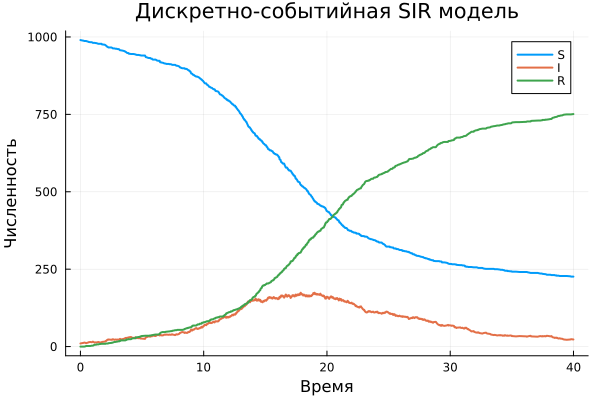

In [5]:
plt_des = @df data_des plot(
    :t,
    [:S :I :R],
    labels = ["S" "I" "R"],
    xlab = "Время",
    ylab = "Численность",
    title = "Дискретно-событийная SIR модель",
    linewidth = 2,
)
savefig(plt_des, plotsdir("sir_des.png"))
plt_des